## v2 — the direct approach, pushed as far as it goes

Everything v1 was missing: a ResNet-50 trunk, aspect-preserving 576x384 input,
photometric augmentation, a frozen-then-unfrozen backbone, flip TTA, and
automatic abstention on direction. Best validation mean IoU **0.4675** against
the 0.4295 baseline -- a 0.038 gain for a great deal of machinery, which is
what finally made the target parameterisation the obvious suspect.

---

**Provenance.** This is an as-run artifact from the BrabantHack 2026 DEMCON
challenge, preserved with its original outputs so the numbers quoted in
[`docs/experiments.md`](../docs/experiments.md) can be checked against the logs
that produced them. Paths are relative to the original repository layout.

The method it arrived at has since been rewritten as a tested package under
[`src/shadow_detection/`](../src/shadow_detection); run
`shadow-detection train --help` rather than this notebook.


# Shadow -> Off-Screen Person Bbox Prediction (v2)

**Key changes from v1:**
1. Aspect-ratio-preserving resize (576x384, not squished 320x320)
2. ResNet50 backbone (2048-dim features vs 512)
3. Photometric augmentation (brightness, contrast, gamma, blur)
4. Backbone frozen for first N epochs, then unfrozen with 10x lower LR
5. Single cosine schedule (no warm restarts -- avoids mid-training regression)
6. GIoU + SmoothL1 combined bbox loss (stable gradients at zero overlap)
7. Direction head uses detached features (cannot corrupt bbox learning)
8. Test-time augmentation (horizontal flip averaging)
9. Auto-abstain on direction if val accuracy < 55%

In [1]:
import torch

# Pick the GPU with the most free memory
best_gpu = 0
best_free = 0
for i in range(torch.cuda.device_count()):
    free, total = torch.cuda.mem_get_info(i)
    used = total - free
    print(f"GPU {i}: {torch.cuda.get_device_name(i)} | {free/1e9:.1f} GB free / {total/1e9:.1f} GB total | {used/1e9:.1f} GB used")
    if free > best_free:
        best_free = free
        best_gpu = i

torch.cuda.set_device(best_gpu)
print(f"\nSelected GPU {best_gpu} ({best_free/1e9:.1f} GB free)")

GPU 0: NVIDIA RTX A6000 | 3.9 GB free / 50.9 GB total | 47.0 GB used
GPU 1: NVIDIA RTX A6000 | 43.3 GB free / 50.9 GB total | 7.6 GB used
GPU 2: NVIDIA RTX 6000 Ada Generation | 40.6 GB free / 50.9 GB total | 10.3 GB used
GPU 3: NVIDIA RTX 6000 Ada Generation | 23.8 GB free / 50.9 GB total | 27.0 GB used
GPU 4: NVIDIA RTX 6000 Ada Generation | 44.5 GB free / 50.9 GB total | 6.3 GB used
GPU 5: NVIDIA RTX 6000 Ada Generation | 45.0 GB free / 50.9 GB total | 5.9 GB used
GPU 6: NVIDIA RTX A6000 | 7.3 GB free / 50.9 GB total | 43.6 GB used
GPU 7: NVIDIA RTX A6000 | 14.1 GB free / 50.9 GB total | 36.8 GB used

Selected GPU 5 (45.0 GB free)


In [2]:
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image, ImageFilter
from torch.utils.data import Dataset, DataLoader, Subset, random_split
from torchvision import models, transforms
from tqdm.auto import tqdm

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PyTorch: 2.6.0+cu124
CUDA available: True
GPU: NVIDIA RTX A6000
VRAM: 50.9 GB


/home/y2a/Hackaton/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# ==========================================================
# Paths -- relative to the directory where this notebook runs
# The notebook should be inside Hackaton/
# ==========================================================
TRAIN_DIR  = Path("../data/train_data/train_data")
TEST_DIR   = Path("../data/test_data/test_data")
SAMPLE_CSV = Path("../data/submission_example.csv")
SUBMISSION_PATH = Path("submission.csv")
CHECKPOINT_PATH = Path("best_model_v2.pt")

# Quick check that paths exist
assert TRAIN_DIR.exists(), f"Train dir not found: {TRAIN_DIR}"
assert TEST_DIR.exists(),  f"Test dir not found: {TEST_DIR}"

n_train_imgs = len(list(TRAIN_DIR.glob("*.png")))
n_test_imgs  = len(list(TEST_DIR.glob("*.png")))
print(f"Train images: {n_train_imgs}")
print(f"Test images:  {n_test_imgs}")

# Show one JSON to confirm format
sample_json = sorted(TRAIN_DIR.glob("*.json"))[0]
with open(sample_json) as f:
    print(f"\nSample annotation ({sample_json.name}):")
    print(json.dumps(json.load(f), indent=2))

Train images: 1692
Test images:  414

Sample annotation (image_0.json):
{
  "file_name": "image_0",
  "walking_into_frame_bool": 1,
  "bbox": {
    "top_left": [
      -228.87714385986328,
      223.6187400817871
    ],
    "top_right": [
      -110.61487913131714,
      223.6187400817871
    ],
    "bottom_left": [
      -228.87714385986328,
      416.3587894439697
    ],
    "bottom_right": [
      -110.61487913131714,
      416.3587894439697
    ]
  }
}


In [4]:
# ===================== Hyperparameters =====================
# Image size: original is 720x480 (W x H). We preserve the 3:2 ratio.
# 576x384 is 0.8x scale -- enough shadow detail, comfortable on 48 GB.
# On RTX A6000 you could go full 720x480 with BATCH_SIZE=16 if needed.
IMG_W = 576
IMG_H = 384

BATCH_SIZE    = 24
EPOCHS        = 120
LR            = 1e-4       # lower than v1 (3e-4) because ResNet50 is deeper
LR_BACKBONE_MULT = 0.1    # backbone gets LR * 0.1 after unfreeze
WEIGHT_DECAY  = 1e-4
FREEZE_EPOCHS = 8          # freeze backbone for initial head warmup

# Loss weights
GIOU_W = 1.0    # primary bbox loss
L1_W   = 0.5    # auxiliary SmoothL1 on coordinates (helps at zero overlap)
DIR_W  = 0.1    # direction loss (small; gradients detached from backbone)

VAL_SPLIT = 0.12   # ~200 val images
SEED = 42

torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Hyperparameters set.")
print(f"Image size: {IMG_W}x{IMG_H} (W x H)")
print(f"Epochs: {EPOCHS}, Batch: {BATCH_SIZE}, LR: {LR}")

Hyperparameters set.
Image size: 576x384 (W x H)
Epochs: 120, Batch: 24, LR: 0.0001


In [5]:
class ShadowDataset(Dataset):
    """
    Loads shadow images with aspect-ratio-preserving resize.

    Augmentations (train only):
      - Horizontal flip (50%): safe because left/right is balanced.
        Flips bbox X coords and direction accordingly.
      - ColorJitter (80%): teaches robustness to shadow intensity.
      - Random gamma (50%): directly changes shadow-to-background contrast,
        which is the primary visual signal.
      - Gaussian blur (20%): reduces reliance on sharp synthetic edges.

    NOT included:
      - Random crop: destroys frame-boundary context (model needs to know
        which edge the person is off-screen from).
      - Large rotation: shadow angle IS the signal.
    """

    def __init__(self, data_dir, img_w=576, img_h=384,
                 is_test=False, augment=False):
        self.data_dir = Path(data_dir)
        self.img_w = img_w
        self.img_h = img_h
        self.is_test = is_test
        self.augment = augment

        self.image_paths = sorted(self.data_dir.glob("*.png"))
        if not self.image_paths:
            self.image_paths = sorted(self.data_dir.glob("*.jpg"))
        assert self.image_paths, f"No images found in {self.data_dir}"

        # ImageNet normalization -- ResNet50 pretrained weights expect this.
        self.normalize = transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        )
        self.color_jitter = transforms.ColorJitter(
            brightness=0.3, contrast=0.3, saturation=0.1, hue=0.02,
        )

    def __len__(self):
        return len(self.image_paths)

    def _random_gamma(self, img, low=0.7, high=1.4):
        gamma = random.uniform(low, high)
        arr = np.asarray(img, dtype=np.float32) / 255.0
        arr = np.clip(arr ** (1.0 / gamma), 0, 1)
        return Image.fromarray((arr * 255).astype(np.uint8))

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        orig_w, orig_h = image.size  # 720, 480

        # Aspect-preserving resize (no squishing!)
        image = image.resize((self.img_w, self.img_h), Image.BILINEAR)

        do_flip  = self.augment and random.random() < 0.5
        do_color = self.augment and random.random() < 0.8
        do_gamma = self.augment and random.random() < 0.5
        do_blur  = self.augment and random.random() < 0.2

        if do_color:
            image = self.color_jitter(image)
        if do_gamma:
            image = self._random_gamma(image)
        if do_blur:
            image = image.filter(ImageFilter.GaussianBlur(
                radius=random.uniform(0.3, 1.2)))
        if do_flip:
            image = image.transpose(Image.FLIP_LEFT_RIGHT)

        image_tensor = transforms.ToTensor()(image)
        image_tensor = self.normalize(image_tensor)

        result = {
            "image": image_tensor,
            "stem": img_path.stem,
            "orig_w": orig_w,
            "orig_h": orig_h,
        }

        if self.is_test:
            return result

        # Load annotation
        json_path = img_path.with_suffix(".json")
        with open(json_path) as f:
            ann = json.load(f)

        bbox = ann["bbox"]
        all_x = [bbox["top_left"][0], bbox["top_right"][0],
                 bbox["bottom_left"][0], bbox["bottom_right"][0]]
        all_y = [bbox["top_left"][1], bbox["top_right"][1],
                 bbox["bottom_left"][1], bbox["bottom_right"][1]]

        # Normalize to [0,1] relative to original image size.
        # Values CAN be <0 or >1 (person is off-screen).
        xmin = min(all_x) / orig_w
        ymin = min(all_y) / orig_h
        xmax = max(all_x) / orig_w
        ymax = max(all_y) / orig_h

        direction = float(ann["walking_into_frame_bool"])

        if do_flip:
            xmin_new = 1.0 - xmax
            xmax_new = 1.0 - xmin
            xmin, xmax = xmin_new, xmax_new
            direction = 1.0 - direction

        result["bbox"] = torch.tensor([xmin, ymin, xmax, ymax],
                                       dtype=torch.float32)
        result["direction"] = torch.tensor(direction, dtype=torch.float32)
        return result

In [6]:
ds_check = ShadowDataset(TRAIN_DIR, img_w=IMG_W, img_h=IMG_H, augment=False)
sample = ds_check[0]
print(f"Image tensor shape: {sample['image'].shape}")
print(f"Bbox (normalized):  {sample['bbox'].numpy().round(3)}")
print(f"Direction:          {sample['direction'].item()}")
print(f"Original size:      {sample['orig_w']}x{sample['orig_h']}")
print(f"Train dataset size: {len(ds_check)}")

# Also verify test dataset loads (no JSON needed)
ds_test_check = ShadowDataset(TEST_DIR, img_w=IMG_W, img_h=IMG_H, is_test=True)
print(f"Test dataset size:  {len(ds_test_check)}")
t = ds_test_check[0]
print(f"Test image shape:   {t['image'].shape}")
print(f"Test stem:          {t['stem']}")

Image tensor shape: torch.Size([3, 384, 576])
Bbox (normalized):  [-0.318  0.466 -0.154  0.867]
Direction:          1.0
Original size:      720x480
Train dataset size: 1692
Test dataset size:  414
Test image shape:   torch.Size([3, 384, 576])
Test stem:          image_1


In [7]:
class ShadowLocalizer(nn.Module):
    """
    ResNet50 backbone -> shared neck -> bbox head + direction head.

    Key design decisions:
      - ResNet50: 2048-dim features capture richer spatial patterns than
        ResNet18's 512-dim. Shadow geometry reasoning benefits from this.
      - BatchNorm in neck: stabilizes training with the wider layers.
      - Direction head receives DETACHED features. In v1, shared gradients
        from BCE direction loss corrupted bbox features (dir accuracy was
        below random at 46%). Detaching prevents this.
      - No sigmoid on bbox output: coordinates can be negative or >1 since
        the person is off-screen.
      - Bias init to approximate dataset mean: gives reasonable IoU from
        epoch 1 instead of random predictions with zero overlap.
    """

    def __init__(self, backbone="resnet50", dropout=0.3):
        super().__init__()

        if backbone == "resnet50":
            base = models.resnet50(weights="IMAGENET1K_V2")
            feat_dim = 2048
        elif backbone == "resnet34":
            base = models.resnet34(weights="IMAGENET1K_V1")
            feat_dim = 512
        elif backbone == "resnet18":
            base = models.resnet18(weights="IMAGENET1K_V1")
            feat_dim = 512
        else:
            raise ValueError(f"Unknown backbone: {backbone}")

        # Everything except the final classification FC
        self.features = nn.Sequential(*list(base.children())[:-1])

        self.neck = nn.Sequential(
            nn.Flatten(),
            nn.Linear(feat_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.5),
        )

        self.bbox_head = nn.Linear(256, 4)

        # Direction head on detached features
        self.dir_head = nn.Sequential(
            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 1),
        )

        # Init bbox bias to dataset mean position
        with torch.no_grad():
            self.bbox_head.bias.copy_(
                torch.tensor([0.0, 0.46, 0.15, 0.84])
            )

    def forward(self, x):
        feats = self.features(x)
        neck_out = self.neck(feats)
        bbox = self.bbox_head(neck_out)
        # Detach: direction gradients do NOT flow into backbone/neck
        dir_logit = self.dir_head(neck_out.detach())
        return bbox, dir_logit

    def freeze_backbone(self):
        for param in self.features.parameters():
            param.requires_grad = False

    def unfreeze_backbone(self):
        for param in self.features.parameters():
            param.requires_grad = True

In [8]:
model_check = ShadowLocalizer("resnet50")
dummy = torch.randn(2, 3, IMG_H, IMG_W)
bbox_out, dir_out = model_check(dummy)
print(f"Bbox output shape: {bbox_out.shape}")
print(f"Dir output shape:  {dir_out.shape}")
print(f"Initial bbox pred: {bbox_out[0].detach().numpy().round(3)}")
n_params = sum(p.numel() for p in model_check.parameters())
n_train_p = sum(p.numel() for p in model_check.parameters() if p.requires_grad)
print(f"Parameters: {n_params:,} total, {n_train_p:,} trainable")
del model_check

Bbox output shape: torch.Size([2, 4])
Dir output shape:  torch.Size([2, 1])
Initial bbox pred: [-0.133  0.815  0.107  1.286]
Parameters: 24,707,525 total, 24,707,525 trainable


In [9]:
def compute_giou(pred, target):
    """Generalized IoU for [xmin, ymin, xmax, ymax] box batches."""
    p_x1 = torch.min(pred[:, 0], pred[:, 2])
    p_y1 = torch.min(pred[:, 1], pred[:, 3])
    p_x2 = torch.max(pred[:, 0], pred[:, 2])
    p_y2 = torch.max(pred[:, 1], pred[:, 3])

    t_x1 = torch.min(target[:, 0], target[:, 2])
    t_y1 = torch.min(target[:, 1], target[:, 3])
    t_x2 = torch.max(target[:, 0], target[:, 2])
    t_y2 = torch.max(target[:, 1], target[:, 3])

    ix1 = torch.max(p_x1, t_x1)
    iy1 = torch.max(p_y1, t_y1)
    ix2 = torch.min(p_x2, t_x2)
    iy2 = torch.min(p_y2, t_y2)
    inter = torch.clamp(ix2 - ix1, min=0) * torch.clamp(iy2 - iy1, min=0)

    p_area = (p_x2 - p_x1) * (p_y2 - p_y1)
    t_area = (t_x2 - t_x1) * (t_y2 - t_y1)
    union = p_area + t_area - inter + 1e-7
    iou = inter / union

    ex1 = torch.min(p_x1, t_x1)
    ey1 = torch.min(p_y1, t_y1)
    ex2 = torch.max(p_x2, t_x2)
    ey2 = torch.max(p_y2, t_y2)
    enclose = (ex2 - ex1) * (ey2 - ey1) + 1e-7

    giou = iou - (enclose - union) / enclose
    return giou, iou


def combined_loss(bbox_pred, bbox_gt, dir_pred, dir_gt):
    """
    GIoU + SmoothL1 for bbox, BCE for direction.

    Why SmoothL1 alongside GIoU:
      When predicted and GT boxes have zero overlap (common early in
      training), GIoU only gets gradients from the enclosing-box penalty.
      SmoothL1 provides direct coordinate-level gradients regardless of
      overlap, stabilizing early training significantly.
    """
    giou, iou = compute_giou(bbox_pred, bbox_gt)
    giou_loss = (1.0 - giou).mean()
    l1_loss = F.smooth_l1_loss(bbox_pred, bbox_gt)
    dir_loss = F.binary_cross_entropy_with_logits(
        dir_pred.squeeze(-1), dir_gt)

    total = GIOU_W * giou_loss + L1_W * l1_loss + DIR_W * dir_loss

    with torch.no_grad():
        dir_acc = ((torch.sigmoid(dir_pred.squeeze(-1)) > 0.5).float()
                   == dir_gt).float().mean().item()

    return total, {
        "loss": total.item(),
        "giou_loss": giou_loss.item(),
        "l1_loss": l1_loss.item(),
        "mean_iou": iou.clamp(min=0).mean().item(),
        "dir_acc": dir_acc,
    }

In [10]:
full_ds = ShadowDataset(TRAIN_DIR, img_w=IMG_W, img_h=IMG_H, augment=False)
n_total = len(full_ds)
n_val = int(n_total * VAL_SPLIT)
n_train = n_total - n_val

train_indices, val_indices = random_split(
    range(n_total), [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED),
)

# Separate instances: train WITH augmentation, val WITHOUT
train_ds = ShadowDataset(TRAIN_DIR, img_w=IMG_W, img_h=IMG_H, augment=True)
val_ds   = ShadowDataset(TRAIN_DIR, img_w=IMG_W, img_h=IMG_H, augment=False)

train_loader = DataLoader(
    Subset(train_ds, train_indices.indices),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True,
    drop_last=True,
)
val_loader = DataLoader(
    Subset(val_ds, val_indices.indices),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True,
)

print(f"Train: {n_train}, Val: {n_val}")
print(f"Batches per epoch: {len(train_loader)}")

Train: 1489, Val: 203
Batches per epoch: 62


In [11]:
model = ShadowLocalizer("resnet50").to(DEVICE)
model.freeze_backbone()

# Two param groups: backbone (low LR) and head/neck (normal LR)
backbone_params = list(model.features.parameters())
head_params = [p for n, p in model.named_parameters()
               if not n.startswith("features")]

optimizer = torch.optim.AdamW([
    {"params": backbone_params, "lr": LR * LR_BACKBONE_MULT},
    {"params": head_params,     "lr": LR},
], weight_decay=WEIGHT_DECAY)

# Single cosine decay -- no warm restarts (v1 restart at epoch 45 caused
# a big regression that wasted ~15 epochs)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=1e-6,
)

print(f"Backbone frozen for first {FREEZE_EPOCHS} epochs")
print(f"Head LR: {LR}, Backbone LR: {LR * LR_BACKBONE_MULT}")
print(f"Scheduler: CosineAnnealingLR T_max={EPOCHS}")

Backbone frozen for first 8 epochs
Head LR: 0.0001, Backbone LR: 1e-05
Scheduler: CosineAnnealingLR T_max=120


In [12]:
history = {
    "train_loss": [], "val_loss": [],
    "train_iou": [], "val_iou": [],
    "train_dir": [], "val_dir": [],
    "lr": [],
}
best_val_iou = -1.0
best_epoch = -1

for epoch in range(EPOCHS):
    if epoch == FREEZE_EPOCHS:
        model.unfreeze_backbone()
        print(f"\n--- Backbone unfrozen at epoch {epoch + 1} ---\n")

    # --- Train ---
    model.train()
    accum = {"loss": 0, "mean_iou": 0, "dir_acc": 0}
    n_batches = 0

    for batch in train_loader:
        images = batch["image"].to(DEVICE)
        bbox_gt = batch["bbox"].to(DEVICE)
        dir_gt = batch["direction"].to(DEVICE)

        bbox_pred, dir_pred = model(images)
        loss, metrics = combined_loss(bbox_pred, bbox_gt, dir_pred, dir_gt)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        for k in accum:
            accum[k] += metrics.get(k, 0)
        n_batches += 1

    scheduler.step()
    train_avg = {k: v / n_batches for k, v in accum.items()}

    # --- Validate ---
    model.eval()
    val_accum = {"loss": 0, "mean_iou": 0, "dir_acc": 0}
    val_n = 0

    with torch.no_grad():
        for batch in val_loader:
            images = batch["image"].to(DEVICE)
            bbox_gt = batch["bbox"].to(DEVICE)
            dir_gt = batch["direction"].to(DEVICE)

            bbox_pred, dir_pred = model(images)
            _, metrics = combined_loss(bbox_pred, bbox_gt, dir_pred, dir_gt)

            for k in val_accum:
                val_accum[k] += metrics.get(k, 0)
            val_n += 1

    val_avg = {k: v / max(1, val_n) for k, v in val_accum.items()}

    history["train_loss"].append(train_avg["loss"])
    history["val_loss"].append(val_avg["loss"])
    history["train_iou"].append(train_avg["mean_iou"])
    history["val_iou"].append(val_avg["mean_iou"])
    history["train_dir"].append(train_avg["dir_acc"])
    history["val_dir"].append(val_avg["dir_acc"])
    history["lr"].append(optimizer.param_groups[1]["lr"])

    saved = ""
    if val_avg["mean_iou"] > best_val_iou:
        best_val_iou = val_avg["mean_iou"]
        best_epoch = epoch + 1
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "val_iou": best_val_iou,
        }, CHECKPOINT_PATH)
        saved = " *BEST*"

    if (epoch + 1) % 5 == 0 or epoch == 0 or saved:
        print(
            f"Epoch {epoch+1:3d}/{EPOCHS} | "
            f"loss={train_avg['loss']:.4f}/{val_avg['loss']:.4f} | "
            f"IoU={train_avg['mean_iou']:.4f}/{val_avg['mean_iou']:.4f} | "
            f"dir={train_avg['dir_acc']:.2f}/{val_avg['dir_acc']:.2f} | "
            f"lr={optimizer.param_groups[1]['lr']:.1e}{saved}"
        )

print(f"\nBest val IoU: {best_val_iou:.4f} at epoch {best_epoch}")
print(f"Baseline (per-edge mean): 0.4295")
print(f"Improvement: {best_val_iou - 0.4295:+.4f}")

Epoch   1/120 | loss=1.6707/1.5582 | IoU=0.0195/0.0259 | dir=0.53/0.44 | lr=1.0e-04 *BEST*
Epoch   5/120 | loss=1.4184/1.3302 | IoU=0.0128/0.0180 | dir=0.49/0.46 | lr=1.0e-04

--- Backbone unfrozen at epoch 9 ---

Epoch  10/120 | loss=1.3148/1.2405 | IoU=0.0148/0.0153 | dir=0.52/0.45 | lr=9.8e-05
Epoch  15/120 | loss=1.2217/1.1583 | IoU=0.0223/0.0269 | dir=0.51/0.47 | lr=9.6e-05 *BEST*
Epoch  16/120 | loss=1.1865/1.1198 | IoU=0.0266/0.0363 | dir=0.52/0.49 | lr=9.6e-05 *BEST*
Epoch  17/120 | loss=1.1677/1.0890 | IoU=0.0314/0.0446 | dir=0.48/0.52 | lr=9.5e-05 *BEST*
Epoch  18/120 | loss=1.1472/1.0721 | IoU=0.0362/0.0506 | dir=0.51/0.48 | lr=9.5e-05 *BEST*
Epoch  19/120 | loss=1.1297/1.0546 | IoU=0.0416/0.0689 | dir=0.52/0.51 | lr=9.4e-05 *BEST*
Epoch  20/120 | loss=1.1196/1.0220 | IoU=0.0473/0.0808 | dir=0.49/0.50 | lr=9.3e-05 *BEST*
Epoch  21/120 | loss=1.1043/1.0085 | IoU=0.0553/0.0899 | dir=0.50/0.51 | lr=9.3e-05 *BEST*
Epoch  22/120 | loss=1.0957/0.9868 | IoU=0.0621/0.1120 | dir=0.52

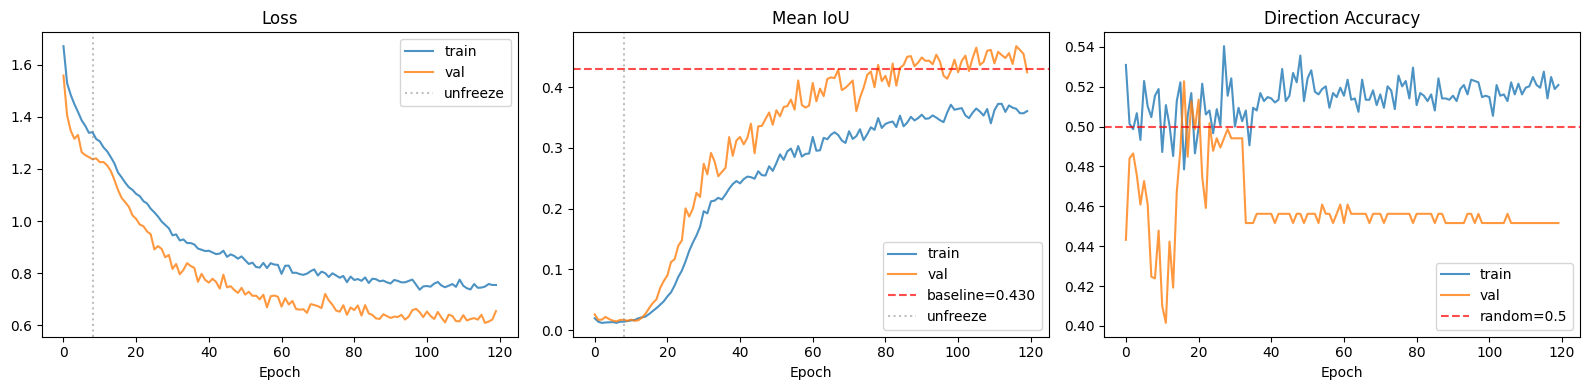

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history["train_loss"], label="train", alpha=0.8)
axes[0].plot(history["val_loss"], label="val", alpha=0.8)
axes[0].axvline(FREEZE_EPOCHS, color="gray", ls=":", alpha=0.5, label="unfreeze")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].set_xlabel("Epoch")

axes[1].plot(history["train_iou"], label="train", alpha=0.8)
axes[1].plot(history["val_iou"], label="val", alpha=0.8)
axes[1].axhline(0.4295, color="red", ls="--", alpha=0.7, label="baseline=0.430")
axes[1].axvline(FREEZE_EPOCHS, color="gray", ls=":", alpha=0.5, label="unfreeze")
axes[1].set_title("Mean IoU"); axes[1].legend(); axes[1].set_xlabel("Epoch")

axes[2].plot(history["train_dir"], label="train", alpha=0.8)
axes[2].plot(history["val_dir"], label="val", alpha=0.8)
axes[2].axhline(0.5, color="red", ls="--", alpha=0.7, label="random=0.5")
axes[2].set_title("Direction Accuracy"); axes[2].legend(); axes[2].set_xlabel("Epoch")

plt.tight_layout()
plt.savefig("training_curves_v2.png", dpi=120, bbox_inches="tight")
plt.show()

In [14]:
ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print(f"Loaded best model from epoch {ckpt['epoch']} (val IoU={ckpt['val_iou']:.4f})")

val_results = []
with torch.no_grad():
    for batch in val_loader:
        images = batch["image"].to(DEVICE)
        bbox_gt_np = batch["bbox"].cpu().numpy()
        dir_gt_np = batch["direction"].cpu().numpy()
        stems = batch["stem"]
        orig_w = batch["orig_w"].numpy()
        orig_h = batch["orig_h"].numpy()

        bbox_pred, dir_pred = model(images)
        bbox_pred_np = bbox_pred.cpu().numpy()
        dir_prob_np = torch.sigmoid(dir_pred).cpu().numpy().squeeze(-1)

        for i in range(len(stems)):
            gt = bbox_gt_np[i]
            pr = bbox_pred_np[i]
            gt_v = [min(gt[0], gt[2]), min(gt[1], gt[3]),
                    max(gt[0], gt[2]), max(gt[1], gt[3])]
            pr_v = [min(pr[0], pr[2]), min(pr[1], pr[3]),
                    max(pr[0], pr[2]), max(pr[1], pr[3])]

            ix1 = max(gt_v[0], pr_v[0])
            iy1 = max(gt_v[1], pr_v[1])
            ix2 = min(gt_v[2], pr_v[2])
            iy2 = min(gt_v[3], pr_v[3])
            inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
            gt_a = (gt_v[2] - gt_v[0]) * (gt_v[3] - gt_v[1])
            pr_a = (pr_v[2] - pr_v[0]) * (pr_v[3] - pr_v[1])
            iou_val = inter / (gt_a + pr_a - inter + 1e-7)

            val_results.append({
                "stem": stems[i], "iou": iou_val,
                "dir_correct": int((dir_prob_np[i] > 0.5) == dir_gt_np[i]),
                "gt_xmin": gt[0], "gt_ymin": gt[1],
                "gt_xmax": gt[2], "gt_ymax": gt[3],
                "pr_xmin": pr[0], "pr_ymin": pr[1],
                "pr_xmax": pr[2], "pr_ymax": pr[3],
                "gt_dir": dir_gt_np[i], "pr_dir_prob": dir_prob_np[i],
            })

val_df = pd.DataFrame(val_results)
dir_acc = val_df["dir_correct"].mean()

print(f"\nValidation ({len(val_df)} images):")
print(f"  Mean IoU:       {val_df['iou'].mean():.4f}")
print(f"  Median IoU:     {val_df['iou'].median():.4f}")
print(f"  IoU > 0.5:      {(val_df['iou'] > 0.5).mean()*100:.1f}%")
print(f"  IoU > 0.3:      {(val_df['iou'] > 0.3).mean()*100:.1f}%")
print(f"  IoU == 0:        {(val_df['iou'] < 0.01).mean()*100:.1f}%")
print(f"  Dir accuracy:   {dir_acc*100:.1f}%")

# Auto-decide direction strategy
USE_DIR_PREDICTIONS = dir_acc > 0.55
if USE_DIR_PREDICTIONS:
    dir_bonus = 0.05 * (2 * dir_acc - 1)
    print(f"  Direction: USING predictions (expected bonus: {dir_bonus:+.4f})")
else:
    print(f"  Direction: ABSTAINING (-1) -- {dir_acc*100:.1f}% is below 55% threshold")

score = val_df["iou"].mean() + (0.05 * (2 * dir_acc - 1) if USE_DIR_PREDICTIONS else 0.0)
print(f"\n  Estimated competition score: {score:.4f}")

Loaded best model from epoch 117 (val IoU=0.4675)

Validation (203 images):
  Mean IoU:       0.4673
  Median IoU:     0.4590
  IoU > 0.5:      41.4%
  IoU > 0.3:      79.3%
  IoU == 0:        0.0%
  Dir accuracy:   46.3%
  Direction: ABSTAINING (-1) -- 46.3% is below 55% threshold

  Estimated competition score: 0.4673


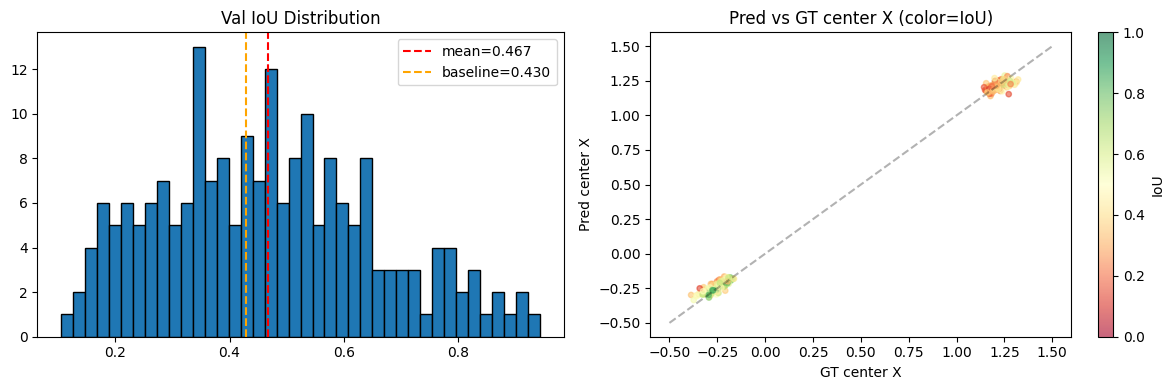


Worst 10 predictions:
  image_2984  : IoU=0.106  GT=RIGHT pred=RIGHT
  image_159   : IoU=0.128  GT=RIGHT pred=RIGHT
  image_2341  : IoU=0.135  GT=LEFT pred=LEFT
  image_2066  : IoU=0.150  GT=RIGHT pred=RIGHT
  image_1384  : IoU=0.163  GT=RIGHT pred=RIGHT
  image_598   : IoU=0.168  GT=RIGHT pred=RIGHT
  image_1026  : IoU=0.168  GT=RIGHT pred=RIGHT
  image_1901  : IoU=0.173  GT=RIGHT pred=RIGHT
  image_1355  : IoU=0.173  GT=RIGHT pred=RIGHT
  image_1791  : IoU=0.177  GT=RIGHT pred=RIGHT


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(val_df["iou"], bins=40, edgecolor="black")
axes[0].axvline(val_df["iou"].mean(), color="red", ls="--",
                label=f"mean={val_df['iou'].mean():.3f}")
axes[0].axvline(0.4295, color="orange", ls="--", label="baseline=0.430")
axes[0].set_title("Val IoU Distribution"); axes[0].legend()

gt_cx = (val_df["gt_xmin"] + val_df["gt_xmax"]) / 2
pr_cx = (val_df["pr_xmin"] + val_df["pr_xmax"]) / 2
sc = axes[1].scatter(gt_cx, pr_cx, c=val_df["iou"], cmap="RdYlGn",
                     alpha=0.6, s=15, vmin=0, vmax=1)
axes[1].plot([-0.5, 1.5], [-0.5, 1.5], "k--", alpha=0.3)
axes[1].set_xlabel("GT center X"); axes[1].set_ylabel("Pred center X")
axes[1].set_title("Pred vs GT center X (color=IoU)")
plt.colorbar(sc, ax=axes[1], label="IoU")

plt.tight_layout()
plt.savefig("val_analysis_v2.png", dpi=120, bbox_inches="tight")
plt.show()

# Worst predictions
print("\nWorst 10 predictions:")
worst = val_df.nsmallest(10, "iou")
for _, row in worst.iterrows():
    gt_side = "LEFT" if row["gt_xmax"] < 0.5 else "RIGHT"
    pr_side = "LEFT" if row["pr_xmax"] < 0.5 else "RIGHT"
    tag = "" if gt_side == pr_side else " << WRONG SIDE"
    print(f"  {row['stem']:12s}: IoU={row['iou']:.3f}  GT={gt_side} pred={pr_side}{tag}")

In [16]:
# Reload best model (in case val analysis cell modified state)
ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

test_ds = ShadowDataset(TEST_DIR, img_w=IMG_W, img_h=IMG_H, is_test=True)
test_loader = DataLoader(test_ds, batch_size=48, shuffle=False, num_workers=2)
print(f"Test set: {len(test_ds)} images")
print(f"TTA: horizontal flip averaging")

predictions = []
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Predicting"):
        images = batch["image"].to(DEVICE)
        stems = batch["stem"]
        orig_w = batch["orig_w"].float()
        orig_h = batch["orig_h"].float()

        # Original forward pass
        bbox_orig, dir_orig = model(images)

        # Flipped forward pass
        images_flip = torch.flip(images, dims=[3])
        bbox_flip, dir_flip = model(images_flip)

        # Un-flip X coordinates
        bbox_flip_c = bbox_flip.clone()
        bbox_flip_c[:, 0] = 1.0 - bbox_flip[:, 2]  # xmin = 1 - xmax_flip
        bbox_flip_c[:, 2] = 1.0 - bbox_flip[:, 0]  # xmax = 1 - xmin_flip

        # Average bbox predictions
        bbox_avg = ((bbox_orig + bbox_flip_c) / 2.0).cpu()

        # Average direction (flip inverts direction)
        dir_prob_orig = torch.sigmoid(dir_orig.squeeze(-1))
        dir_prob_flip = torch.sigmoid(dir_flip.squeeze(-1))
        dir_prob_avg = ((dir_prob_orig + (1.0 - dir_prob_flip)) / 2.0).cpu()

        for i in range(len(stems)):
            w = orig_w[i].item()
            h = orig_h[i].item()
            if USE_DIR_PREDICTIONS:
                direction = 1 if dir_prob_avg[i].item() > 0.5 else 0
            else:
                direction = -1

            predictions.append({
                "id": stems[i],
                "xmin": bbox_avg[i, 0].item() * w,
                "ymin": bbox_avg[i, 1].item() * h,
                "xmax": bbox_avg[i, 2].item() * w,
                "ymax": bbox_avg[i, 3].item() * h,
                "direction": direction,
            })

pred_df = pd.DataFrame(predictions)
print(f"\nPredictions: {len(pred_df)} rows")
print(f"  xmin range: [{pred_df['xmin'].min():.1f}, {pred_df['xmin'].max():.1f}]")
print(f"  xmax range: [{pred_df['xmax'].min():.1f}, {pred_df['xmax'].max():.1f}]")
print(f"  direction:  {pred_df['direction'].value_counts().to_dict()}")

Test set: 414 images
TTA: horizontal flip averaging


Predicting: 100%|██████████| 9/9 [00:04<00:00,  1.86it/s]



Predictions: 414 rows
  xmin range: [-304.0, 844.7]
  xmax range: [-138.2, 1004.5]
  direction:  {-1: 414}


In [17]:
# Load sample submission to get exact IDs and row order
sample_sub = pd.read_csv(SAMPLE_CSV)
print(f"Sample submission: {len(sample_sub)} rows, columns={list(sample_sub.columns)}")

# Merge predictions with sample to match exact order
submission = sample_sub[["id"]].merge(pred_df, on="id", how="left")

# Fill any missing predictions with the sample's default values
missing = submission["xmin"].isna().sum()
if missing > 0:
    print(f"WARNING: {missing} test IDs not found in predictions, filling with defaults")
    submission = submission.fillna({
        "xmin": -200.0, "ymin": 220.0, "xmax": -120.0, "ymax": 380.0,
        "direction": -1,
    })

submission["direction"] = submission["direction"].astype(int)
submission.to_csv(SUBMISSION_PATH, index=False)

print(f"\nSubmission saved: {SUBMISSION_PATH}")
print(f"Shape: {submission.shape}")
print(f"Columns: {list(submission.columns)}")
print(f"\nFirst 5 rows:")
print(submission.head().to_string())

# Final verification
reload = pd.read_csv(SUBMISSION_PATH)
assert list(reload.columns) == ["id", "xmin", "ymin", "xmax", "ymax", "direction"], \
    f"Column mismatch: {list(reload.columns)}"
assert len(reload) == len(sample_sub), \
    f"Row count mismatch: {len(reload)} vs {len(sample_sub)}"
print(f"\nVerification passed: {len(reload)} rows, correct columns, direction values={sorted(reload['direction'].unique())}")

Sample submission: 414 rows, columns=['id', 'xmin', 'ymin', 'xmax', 'ymax', 'direction']

Submission saved: submission.csv
Shape: (414, 6)
Columns: ['id', 'xmin', 'ymin', 'xmax', 'ymax', 'direction']

First 5 rows:
           id        xmin        ymin        xmax        ymax  direction
0     image_1  801.465511  220.456853  952.276554  404.960403         -1
1  image_1002  782.283039  223.874388  918.032513  364.323893         -1
2  image_1014 -298.456178  217.663593 -133.826244  443.782654         -1
3  image_1017 -265.645294  218.604069 -112.062006  421.266632         -1
4  image_1032 -268.812876  219.432163 -113.898697  421.980829         -1

Verification passed: 414 rows, correct columns, direction values=[np.int64(-1)]


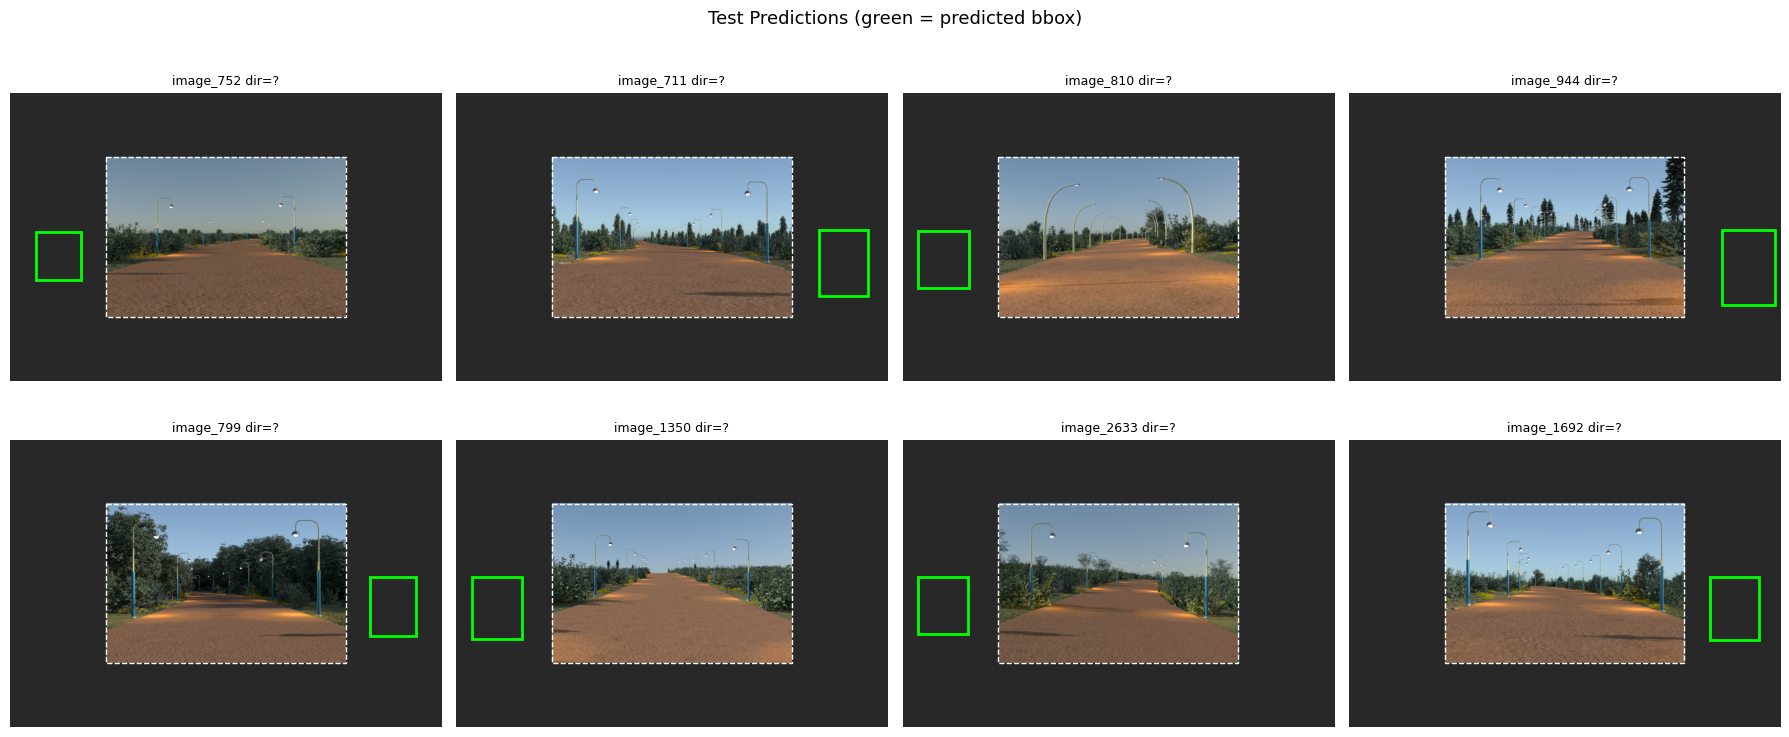

In [18]:
def show_prediction(stem, pred_row, ax, data_dir, pad_ratio=0.4):
    img_path = data_dir / f"{stem}.png"
    if not img_path.exists():
        img_path = data_dir / f"{stem}.jpg"
    img = np.asarray(Image.open(img_path).convert("RGB"))
    h, w = img.shape[:2]
    pad_x, pad_y = int(w * pad_ratio), int(h * pad_ratio)

    canvas = np.full((h + 2*pad_y, w + 2*pad_x, 3), 40, dtype=np.uint8)
    canvas[pad_y:pad_y+h, pad_x:pad_x+w] = img
    ax.imshow(canvas)

    frame = mpatches.Rectangle((pad_x, pad_y), w, h,
                                lw=1, ec="white", fc="none", ls="--")
    ax.add_patch(frame)

    bx = pred_row["xmin"] + pad_x
    by = pred_row["ymin"] + pad_y
    bw = pred_row["xmax"] - pred_row["xmin"]
    bh = pred_row["ymax"] - pred_row["ymin"]
    rect = mpatches.Rectangle((bx, by), bw, bh, lw=2, ec="lime", fc="none")
    ax.add_patch(rect)

    d_str = {1: "INTO", 0: "OUT", -1: "?"}[pred_row["direction"]]
    ax.set_title(f"{stem} dir={d_str}", fontsize=9)
    ax.axis("off")

n_show = min(8, len(pred_df))
show_df = pred_df.sample(n=n_show, random_state=42).reset_index(drop=True)
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, (_, row) in enumerate(show_df.iterrows()):
    show_prediction(row["id"], row, axes.flatten()[i], TEST_DIR)
for i in range(n_show, 8):
    axes.flatten()[i].axis("off")
plt.suptitle("Test Predictions (green = predicted bbox)", fontsize=13)
plt.tight_layout()
plt.savefig("test_predictions_v2.png", dpi=120, bbox_inches="tight")
plt.show()

In [19]:
print("=" * 60)
print("RESULTS SUMMARY (v2)")
print("=" * 60)
print(f"Best val IoU:         {best_val_iou:.4f}")
print(f"Best epoch:           {best_epoch}")
print(f"Baseline (per-edge):  0.4295")
print(f"Improvement:          {best_val_iou - 0.4295:+.4f}")
print(f"Val dir accuracy:     {dir_acc*100:.1f}%")
print(f"Dir strategy:         {'predictions' if USE_DIR_PREDICTIONS else 'abstain (-1)'}")
print(f"Est. competition:     {score:.4f}")
print(f"Submission:           {SUBMISSION_PATH} ({len(submission)} rows)")

RESULTS SUMMARY (v2)
Best val IoU:         0.4675
Best epoch:           117
Baseline (per-edge):  0.4295
Improvement:          +0.0380
Val dir accuracy:     46.3%
Dir strategy:         abstain (-1)
Est. competition:     0.4673
Submission:           submission.csv (414 rows)
